In [1]:
import numpy as np

from easydynamics.sample import GaussianComponent
from easydynamics.sample import LorentzianComponent
from easydynamics.sample import VoigtComponent
from easydynamics.sample import DHOComponent
from easydynamics.sample import PolynomialComponent
from easydynamics.sample import SampleModel

from easydynamics.resolution import ResolutionHandler

import matplotlib.pyplot as plt


from easydynamics.utils import detailed_balance_factor

from easyscience.variable import Parameter
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from scipy.signal import fftconvolve

# Define parameter grid

sigmas=np.linspace(0.001,1,51)
gammas=np.linspace(0.001,1,52)
temperatures = np.linspace(0.0, 300, 12)  # K

# sigmas = np.array([0.001, 0.003, 0.005, 0.01, 0.02])     # Gaussian widths [meV]
# gammas = np.array([0.001, 0.003, 0.005, 0.01, 0.02])     # Lorentzian widths [meV]
# temperatures = np.array([0.0, 0.1, 0.3, 0.5, 1.0, 2.0])  # K

# Energy axis
x = np.linspace(-10, 10, 20000)

# Allocate 3D arrays for deviation metrics
l2_grid = np.zeros((len(gammas), len(sigmas), len(temperatures)))
max_grid = np.zeros_like(l2_grid)
int_grid = np.zeros_like(l2_grid)

l2_grid_no_DBF = np.zeros_like(l2_grid)
max_grid_no_DBF = np.zeros_like(l2_grid)
int_grid_no_DBF = np.zeros_like(l2_grid)

# Loop over parameter combinations
for i_g, gamma in enumerate(gammas):
    for i_s, sigma in enumerate(sigmas):
        for i_t, T in enumerate(temperatures):
            # Create model components
            G = GaussianComponent(center=0, width=sigma, area=1)
            L = LorentzianComponent(center=0, width=gamma, area=1)
            V = VoigtComponent(center=0, Gwidth=sigma, Lwidth=gamma, area=1)

            dbf = detailed_balance_factor(x, T)

            # Analytical: Voigt × DBF
            ana = V.evaluate(x) * dbf
            ana_no_DBF = V.evaluate(x)

            # Numerical: (Lorentzian × DBF) ⊗ Gaussian
            num_signal = L.evaluate(x) * dbf
            num_resolution = G.evaluate(x)
            num = fftconvolve(num_signal, num_resolution, mode='same')
            num *= (x[1] - x[0])

            num_signal_no_DBF = L.evaluate(x)
            num_no_DBF = fftconvolve(num_signal_no_DBF, num_resolution, mode='same')
            num_no_DBF *= (x[1] - x[0])

            # Deviation metrics
            l2 = np.sqrt(np.mean((ana - num)**2))
            maxdev = np.max(np.abs(ana - num))
            intdev = np.trapz(np.abs(ana - num), x)

            l2_no_DBF = np.sqrt(np.mean((ana_no_DBF - num_no_DBF)**2))
            maxdev_no_DBF = np.max(np.abs(ana_no_DBF - num_no_DBF))
            intdev_no_DBF = np.trapz(np.abs(ana_no_DBF - num_no_DBF), x)

            # Store in grid
            l2_grid[i_g, i_s, i_t] = l2
            max_grid[i_g, i_s, i_t] = maxdev
            int_grid[i_g, i_s, i_t] = intdev

            l2_grid_no_DBF[i_g, i_s, i_t] = l2_no_DBF
            max_grid_no_DBF[i_g, i_s, i_t] = maxdev_no_DBF
            int_grid_no_DBF[i_g, i_s, i_t] = intdev_no_DBF


C:\Users\henrikjacobsen3\AppData\Local\Temp\ipykernel_50728\2758449018.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  intdev = np.trapz(np.abs(ana - num), x)
C:\Users\henrikjacobsen3\AppData\Local\Temp\ipykernel_50728\2758449018.py:60: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  intdev_no_DBF = np.trapz(np.abs(ana_no_DBF - num_no_DBF), x)


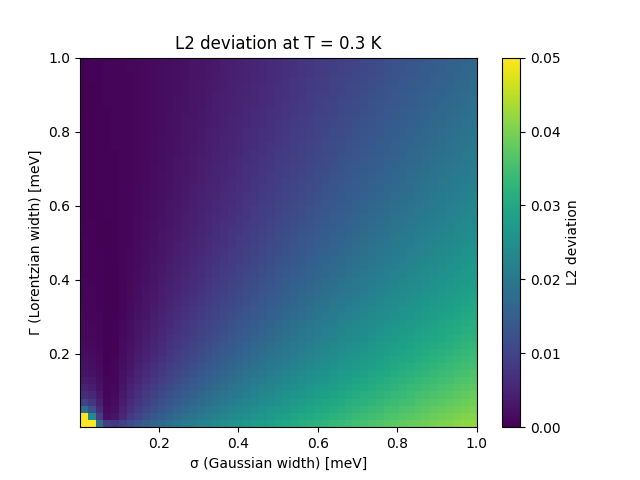

In [3]:
import matplotlib.ticker as ticker

# t_idx = np.where(temperatures == 0.3)[0][0]
t_idx=2
fig_static, ax_static = plt.subplots()
im = ax_static.imshow(l2_grid[:, :, t_idx], origin='lower', cmap='viridis',
               extent=[sigmas[0], sigmas[-1], gammas[0], gammas[-1]],
               aspect='auto',vmin=0,vmax=0.05)

ax_static.set_xlabel("σ (Gaussian width) [meV]")
ax_static.set_ylabel("Γ (Lorentzian width) [meV]")
ax_static.set_title("L2 deviation at T = 0.3 K")
fig_static.colorbar(im, ax=ax_static, label='L2 deviation')
# ax_static.xaxis.set_major_locator(ticker.FixedLocator(sigmas))
# ax_static.yaxis.set_major_locator(ticker.FixedLocator(gammas))

plt.show()


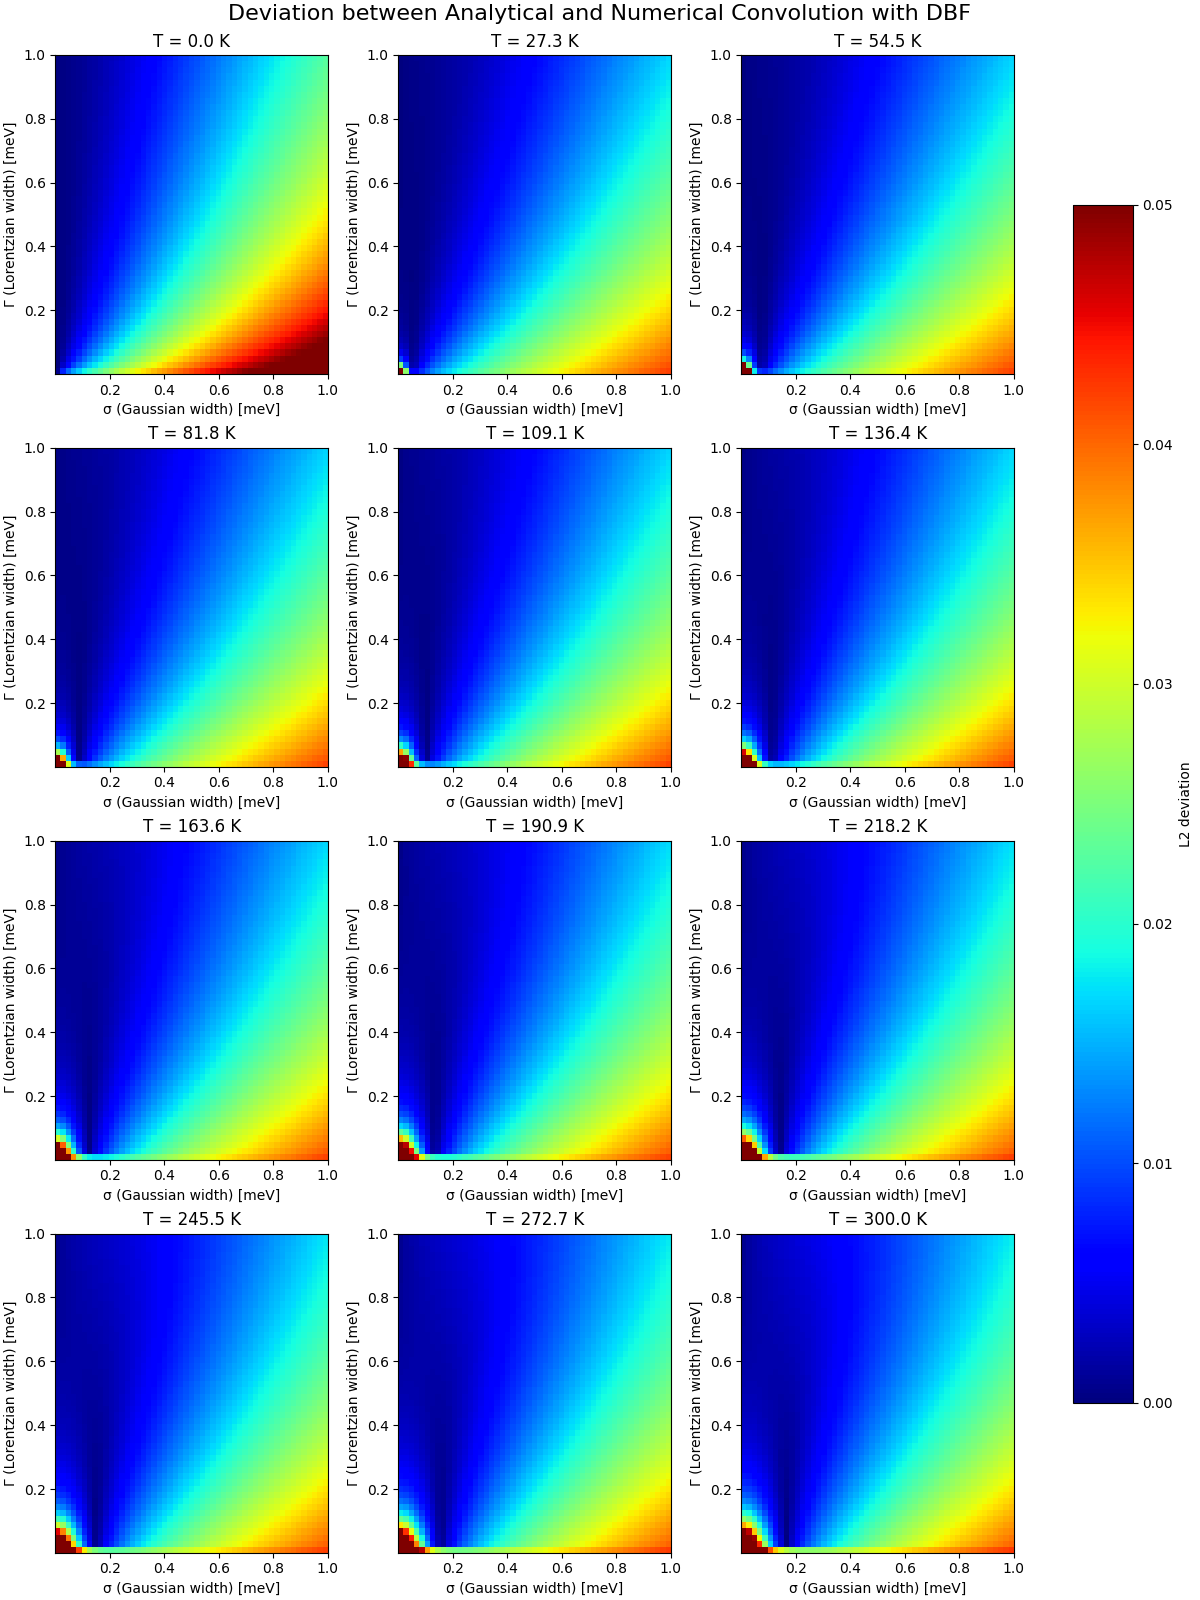

In [4]:
import matplotlib.pyplot as plt

n_rows = 4
n_cols = int(np.ceil(len(temperatures) / n_rows))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), constrained_layout=True)

vmin = 0
vmax = 0.05  # or use np.max(l2_grid) if you want auto-scaling

for idx, T in enumerate(temperatures):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row, col] if n_rows > 1 else axes[col]

    im = ax.imshow(
        l2_grid[:, :, idx],
        origin='lower',
        cmap='jet',
        extent=[sigmas[0], sigmas[-1], gammas[0], gammas[-1]],
        aspect='auto',
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(f"T = {T:.1f} K")
    ax.set_xlabel("σ (Gaussian width) [meV]")
    ax.set_ylabel("Γ (Lorentzian width) [meV]")

# Add one colorbar for the whole figure
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="L2 deviation")

plt.suptitle("Deviation between Analytical and Numerical Convolution with DBF", fontsize=16)
plt.show()


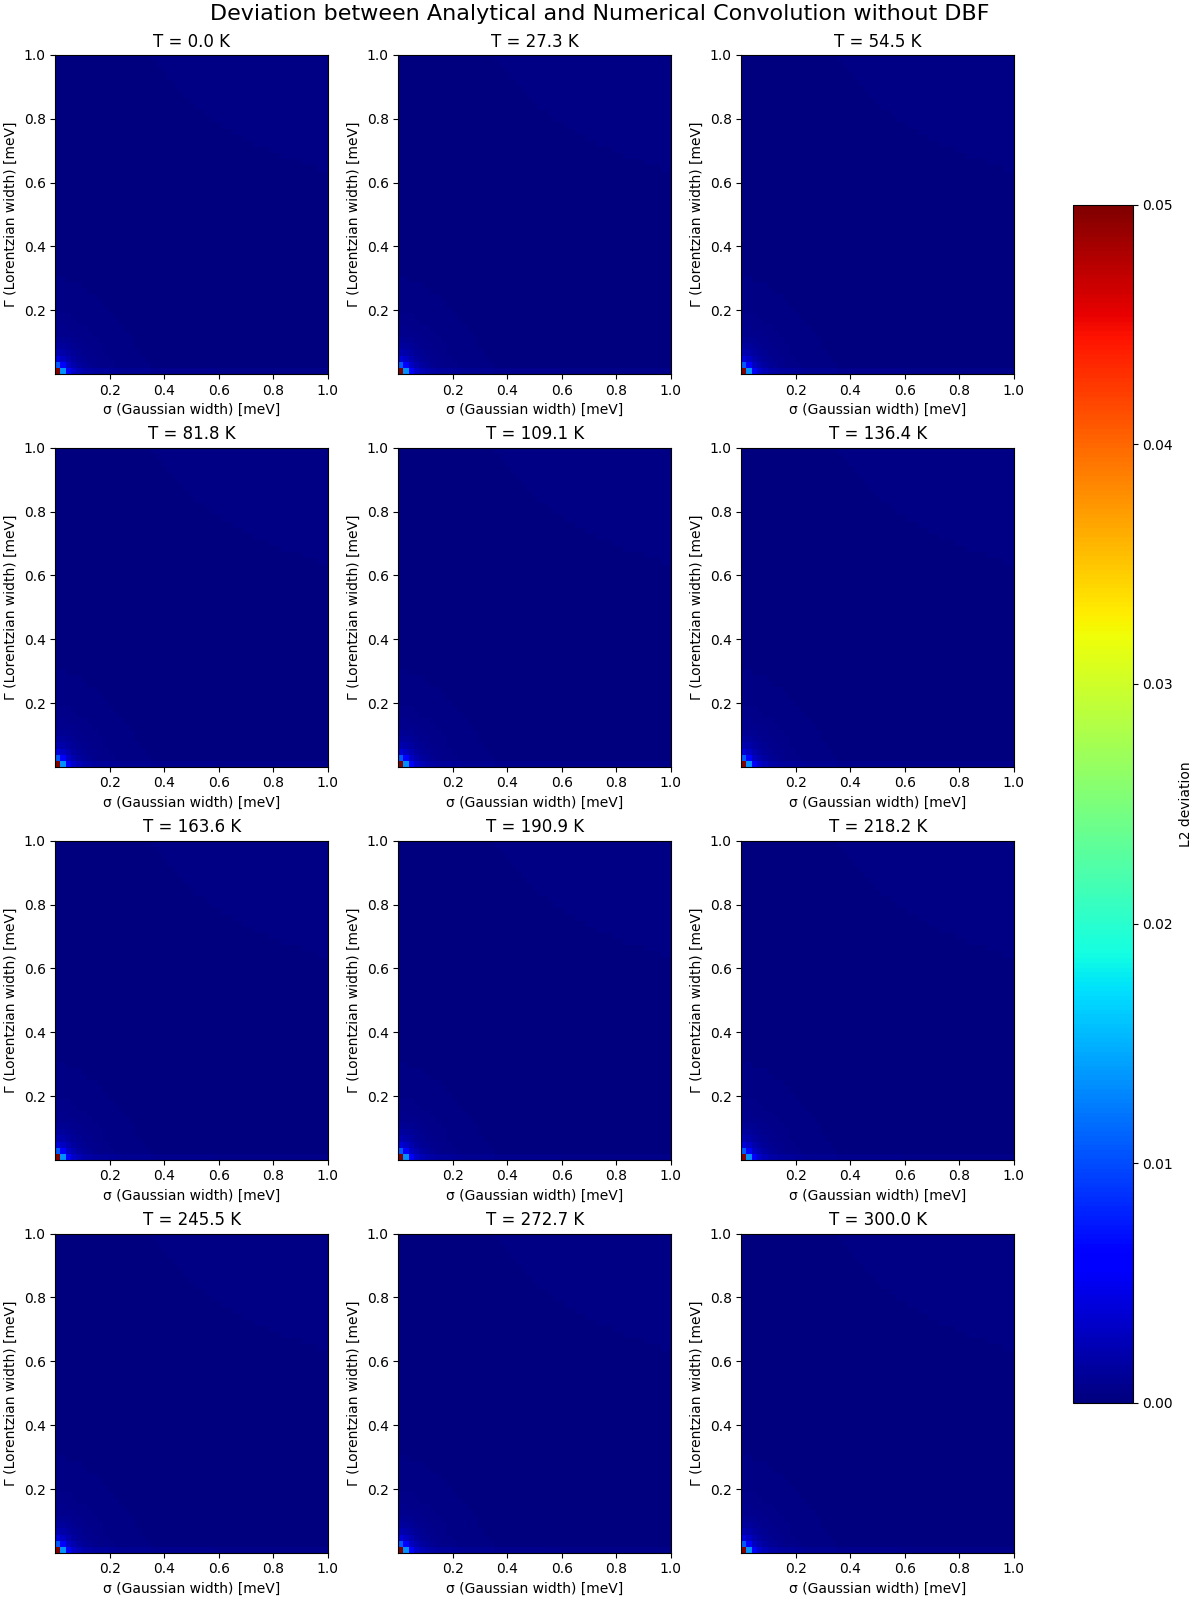

In [5]:
import matplotlib.pyplot as plt

n_rows = 4
n_cols = int(np.ceil(len(temperatures) / n_rows))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), constrained_layout=True)

vmin = 0
vmax = 0.05  # or use np.max(l2_grid) if you want auto-scaling

for idx, T in enumerate(temperatures):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row, col] if n_rows > 1 else axes[col]

    im = ax.imshow(
        l2_grid_no_DBF[:, :, idx],
        origin='lower',
        cmap='jet',
        extent=[sigmas[0], sigmas[-1], gammas[0], gammas[-1]],
        aspect='auto',
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(f"T = {T:.1f} K")
    ax.set_xlabel("σ (Gaussian width) [meV]")
    ax.set_ylabel("Γ (Lorentzian width) [meV]")

# Add one colorbar for the whole figure
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="L2 deviation")

plt.suptitle("Deviation between Analytical and Numerical Convolution without DBF", fontsize=16)
plt.show()
